In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
G = nx.Graph([(0, 1), (0, 2), (0, 3), (1, 2), (1, 3)])
raw_deg = nx.degree_centrality(G)

In [6]:
sorted_deg = sorted(raw_deg.items(), key=lambda x: x[1], reverse=True)
print(sorted_deg)

[(0, 1.0), (1, 1.0), (2, 0.6666666666666666), (3, 0.6666666666666666)]


In [8]:
# betweenness centrality
raw_bet = nx.betweenness_centrality(G)

In [9]:
print(raw_bet)

{0: 0.16666666666666666, 1: 0.16666666666666666, 2: 0.0, 3: 0.0}


In [2]:
df = pd.read_csv('../data/facebook_combined.txt', sep=' ', names=['first_node', 'last_node'])
df.head()

,first_node,last_node
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5


In [3]:
G = nx.Graph()
G.add_edges_from(df.values)

In [4]:
G.degree

DegreeView({np.int64(0): 347, np.int64(1): 17, np.int64(2): 10, np.int64(3): 17, np.int64(4): 10, np.int64(5): 13, np.int64(6): 6, np.int64(7): 20, np.int64(8): 8, np.int64(9): 57, np.int64(10): 10, np.int64(11): 1, np.int64(12): 1, np.int64(13): 31, np.int64(14): 15, np.int64(15): 1, np.int64(16): 9, np.int64(17): 13, np.int64(18): 1, np.int64(19): 16, np.int64(20): 15, np.int64(21): 65, np.int64(22): 11, np.int64(23): 17, np.int64(24): 16, np.int64(25): 69, np.int64(26): 68, np.int64(27): 5, np.int64(28): 13, np.int64(29): 13, np.int64(30): 17, np.int64(31): 23, np.int64(32): 6, np.int64(33): 2, np.int64(34): 5, np.int64(35): 2, np.int64(36): 11, np.int64(37): 1, np.int64(38): 9, np.int64(39): 15, np.int64(40): 44, np.int64(41): 24, np.int64(42): 2, np.int64(43): 1, np.int64(44): 6, np.int64(45): 12, np.int64(46): 5, np.int64(47): 2, np.int64(48): 22, np.int64(49): 4, np.int64(50): 11, np.int64(51): 7, np.int64(52): 2, np.int64(53): 31, np.int64(54): 8, np.int64(55): 17, np.int64(56)

In [8]:
# The core number of a node is the largest value k of a k-core containing that node.
core_num = nx.core_number(G)
sorted_dict = dict(sorted(core_num.items(), key=lambda d: d[1], reverse=True))

#ks = list(core_num.values())
for n in G.nodes():
    print(sorted_dict[n])

21
13
9
13
9
10
5
12
5
21
10
1
1
21
10
1
9
9
1
7
9
21
9
7
15
21
21
5
10
9
14
14
6
2
5
2
10
1
8
12
21
10
2
1
6
11
5
2
14
2
10
7
2
15
7
17
21
12
6
17
8
3
19
6
7
11
15
21
7
10
2
3
18
9
1
12
3
5
9
12
15
2
18
7
10
12
6
11
13
5
2
5
15
6
15
5
8
3
21
7
7
15
6
14
21
12
8
70
11
21
5
9
3
21
1
10
10
5
21
21
3
10
21
17
3
4
6
11
21
7
13
7
13
15
17
10
67
9
2
9
9
19
21
7
10
2
9
5
14
10
7
7
5
2
2
3
10
3
17
11
2
19
8
6
3
10
4
6
9
21
21
7
21
6
3
7
13
7
11
2
15
9
3
2
11
18
21
15
21
7
4
3
2
4
15
9
13
11
7
21
21
4
4
21
15
2
4
3
7
1
1
21
15
19
9
1
2
7
9
5
4
8
10
21
19
7
10
7
3
5
4
15
18
2
2
5
19
7
18
21
3
2
15
6
2
5
12
3
17
15
5
10
21
3
15
2
2
13
12
5
6
21
4
6
5
21
15
2
11
5
3
21
21
9
12
9
16
21
7
2
21
11
2
4
11
21
2
1
4
4
13
19
1
3
3
10
6
21
11
15
7
2
15
14
21
2
9
3
16
10
7
7
10
21
11
21
2
7
11
5
11
3
21
21
18
21
10
4
9
15
14
16
21
8
18
1
3
6
7
14
6
12
21
10
8
13
15
7
31
31
31
43
115
2
4
4
4
14
4
31
31
31
31
21
26
31
35
31
31
39
31
30
31
31
25
21
31
11
31
27
5
29
37
50
32
3
13
23
37
23
2
15
61
13
16
9
5
1
6

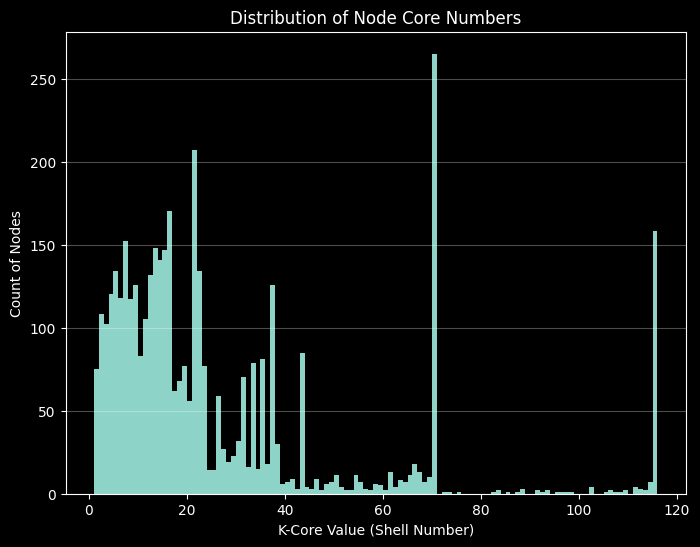

In [22]:
plt.figure(figsize=(8, 6))
plt.hist(ks, bins=range(min(ks), max(ks)+2))

plt.title('Distribution of Node Core Numbers')
plt.xlabel('K-Core Value (Shell Number)')
plt.ylabel('Count of Nodes')
plt.grid(axis='y', alpha=0.3)
plt.show()

- The main core of the network is k = 116(approx) core.
- k-core 71(approx) is the majority of the nodes (the crowd)

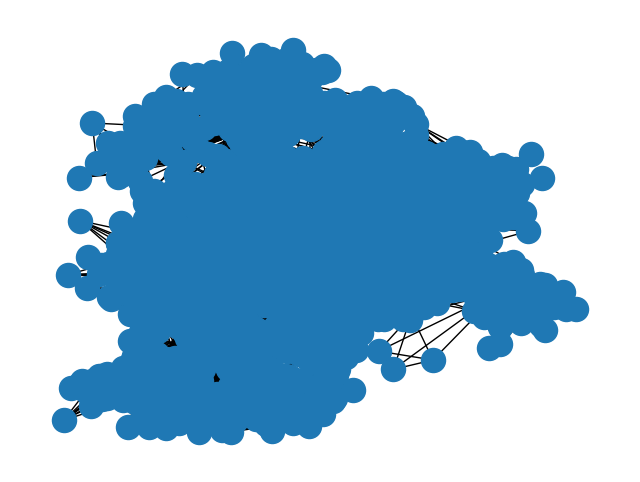

In [6]:
H = G.copy()
H = nx.k_core(G)
fig, ax = plt.subplots(figsize=(8,6))
nx.draw(G, ax=ax)
plt.show()

In [11]:
node_truss = {}
k=2
while True:
    try:
        H = nx.k_truss(G, k)
    except nx.NetworkXError:
        break

    for node in H.nodes():
        node_truss[node] = k

    k += 1

print(node_truss[:5])


KeyboardInterrupt: 

In [16]:
node_truss = {}
k=2
H = G.copy()

while True:
    H_next = nx.k_truss(H, k)

    if H_next.number_of_nodes() <= 2:
        break

    for node in H_next.nodes():
        node_truss[node] = k

    H = H_next
    k += 1

print(node_truss)

KeyboardInterrupt: 

In [25]:
# Checking the output of common_neighbors and assigning values in dictionary
support = {}
support[(0, 1)] = len(list(nx.common_neighbors(G, 0, 1)))
print(support)

{(0, 1): 16}


In [27]:
# Returns edges connected to node 0
G.edges(0)

EdgeDataView([(0, np.int64(1)), (0, np.int64(2)), (0, np.int64(3)), (0, np.int64(4)), (0, np.int64(5)), (0, np.int64(6)), (0, np.int64(7)), (0, np.int64(8)), (0, np.int64(9)), (0, np.int64(10)), (0, np.int64(11)), (0, np.int64(12)), (0, np.int64(13)), (0, np.int64(14)), (0, np.int64(15)), (0, np.int64(16)), (0, np.int64(17)), (0, np.int64(18)), (0, np.int64(19)), (0, np.int64(20)), (0, np.int64(21)), (0, np.int64(22)), (0, np.int64(23)), (0, np.int64(24)), (0, np.int64(25)), (0, np.int64(26)), (0, np.int64(27)), (0, np.int64(28)), (0, np.int64(29)), (0, np.int64(30)), (0, np.int64(31)), (0, np.int64(32)), (0, np.int64(33)), (0, np.int64(34)), (0, np.int64(35)), (0, np.int64(36)), (0, np.int64(37)), (0, np.int64(38)), (0, np.int64(39)), (0, np.int64(40)), (0, np.int64(41)), (0, np.int64(42)), (0, np.int64(43)), (0, np.int64(44)), (0, np.int64(45)), (0, np.int64(46)), (0, np.int64(47)), (0, np.int64(48)), (0, np.int64(49)), (0, np.int64(50)), (0, np.int64(51)), (0, np.int64(52)), (0, np.

In [32]:
support = {}
for (u, v) in G.edges():
    support[(u, v)] = len(list(nx.common_neighbors(G, u, v)))

print(support[0, 1])

16


In [43]:
edge_truss = {}
for (u, v) in G.edges():
    truss_lvl = support[(u, v)] + 2
    edge_truss[(u, v)] = truss_lvl

print(edge_truss[0, 1])

18


In [51]:
node_truss = {}
for (u, v), truss_lvl in edge_truss.items():
    node_truss[u] = max(2, truss_lvl)
    node_truss[v] = max(2, truss_lvl)

print(node_truss[0])
print(type(node_truss))

8
<class 'dict'>


In [52]:
truss_levels = {}
H = G.copy()

current_k = 2
while H.number_of_edges() > 0:
    try:
        H = nx.k_truss(G, current_k)
        for node in H.nodes():
            truss_levels[node] = current_k
        current_k += 1
    except nx.NetworkXError:
        break

print(truss_levels)

{np.int64(0): 18, np.int64(1): 7, np.int64(2): 9, np.int64(3): 12, np.int64(4): 10, np.int64(5): 5, np.int64(6): 6, np.int64(7): 8, np.int64(8): 6, np.int64(9): 18, np.int64(10): 9, np.int64(11): 2, np.int64(12): 2, np.int64(13): 16, np.int64(14): 10, np.int64(15): 2, np.int64(16): 6, np.int64(17): 9, np.int64(18): 2, np.int64(19): 7, np.int64(20): 9, np.int64(21): 18, np.int64(22): 6, np.int64(23): 5, np.int64(24): 14, np.int64(25): 18, np.int64(26): 18, np.int64(27): 5, np.int64(28): 10, np.int64(29): 7, np.int64(30): 9, np.int64(31): 11, np.int64(32): 7, np.int64(33): 3, np.int64(34): 4, np.int64(35): 3, np.int64(36): 11, np.int64(37): 2, np.int64(38): 5, np.int64(39): 8, np.int64(40): 15, np.int64(41): 10, np.int64(42): 3, np.int64(43): 2, np.int64(44): 7, np.int64(45): 9, np.int64(46): 6, np.int64(47): 3, np.int64(48): 6, np.int64(49): 3, np.int64(50): 6, np.int64(51): 7, np.int64(52): 3, np.int64(53): 14, np.int64(54): 5, np.int64(55): 14, np.int64(56): 18, np.int64(57): 9, np.in